# Implement Linear Algebraic understanding through numpy

In [1]:
import numpy as np

### Basic Linear Algebra Functions in NumPy (`numpy` & `np.linalg`)

##### Function Summary

| # | Function | Operation | Mathematical Formula / Concept |
| :--- | :--- | :--- | :--- |
| 1 | `np.dot(a, b)` | Dot Product / Matrix Multiplication | $\langle a, b \rangle = a^T b$ or $C = AB$ |
| 2 | `np.linalg.norm(x)` | Euclidean Norm (Vector/Matrix Magnitude) | $\|x\|_2 = \sqrt{\sum x_i^2}$ |
| 3 | `A.T` | Matrix Transpose | Rows become columns ($A^T_{ij} = A_{ji}$) |
| 4 | `np.linalg.matrix_rank(A)` | Rank Calculation | Count of linearly independent rows/columns |
| 5 | `np.linalg.det(A)` | Determinant | Volume scaling factor of linear map |
| 6 | `np.linalg.inv(A)` | Matrix Inverse | $A^{-1}$ such that $A A^{-1} = I$ |

---

### Vector Projection and Orthogonality

The projection of vector $b$ onto vector $a$ gives the component of $b$ acting along the direction of $a$:
$$\text{proj}_a(b) = \frac{\langle a, b \rangle}{\|a\|^2} a = \frac{a^T b}{a^T a} a$$

The remainder vector $r = b - \text{proj}_a(b)$ is the **orthogonal residual** 

In [2]:
# Problem: Vector Projection and Orthogonality
#
# Given two vectors:
#   a = [2, 1, 3]
#   b = [1, 4, 2]
#
# Tasks:
# 1. Compute the projection of b onto a
# 2. Compute the orthogonal residual r = b - proj_a(b)
# 3. Verify that r is orthogonal to a by checking that dot(a, r) ≈ 0
# 4. Verify that proj_a(b) + r = b (reconstruction)
# 5. Compute the norms of b, proj_a(b), and r
#    and verify Pythagoras: ||b||^2 = ||proj||^2 + ||r||^2

b = np.array([1,4,2])
a = np.array([2,1,3])

# 1. Compute the projection of b onto a
proj_a_b = (np.dot(a,b)/np.linalg.norm(a)**2) * a
print(f"Projection of b onto a: {proj_a_b}")

#2. the orthogonal residual r = b - proj_a(b)
r = b - proj_a_b
print(f"Residual r: {r}")

#3. Verify Orthogonality of r w.r.t a
is_orthogonal = np.isclose(np.dot(a,r),0)
print(f"Is r orthogonal to a? {is_orthogonal}")

#4.Reconstruct b and verify
check_b = proj_a_b + r
print(f"Check reconstruction: {np.allclose(b,check_b)}")

#5. Computing norms
print(f"Norm of b:{np.linalg.norm(b)}")
print(f"Norm of proj_a(b):{np.linalg.norm(proj_a_b)}")
print(f"Norm of r:{np.linalg.norm(r)}")

# Verify Pythagoras theorem
pythagoras_check = np.isclose(np.linalg.norm(b)**2, np.linalg.norm(proj_a_b)**2 + np.linalg.norm(r)**2)
print(f"Does Pythagoras theorem hold? {pythagoras_check}")

Projection of b onto a: [1.71428571 0.85714286 2.57142857]
Residual r: [-0.71428571  3.14285714 -0.57142857]
Is r orthogonal to a? True
Check reconstruction: True
Norm of b:4.58257569495584
Norm of proj_a(b):3.2071349029490923
Norm of r:3.2732683535398857
Does Pythagoras theorem hold? True


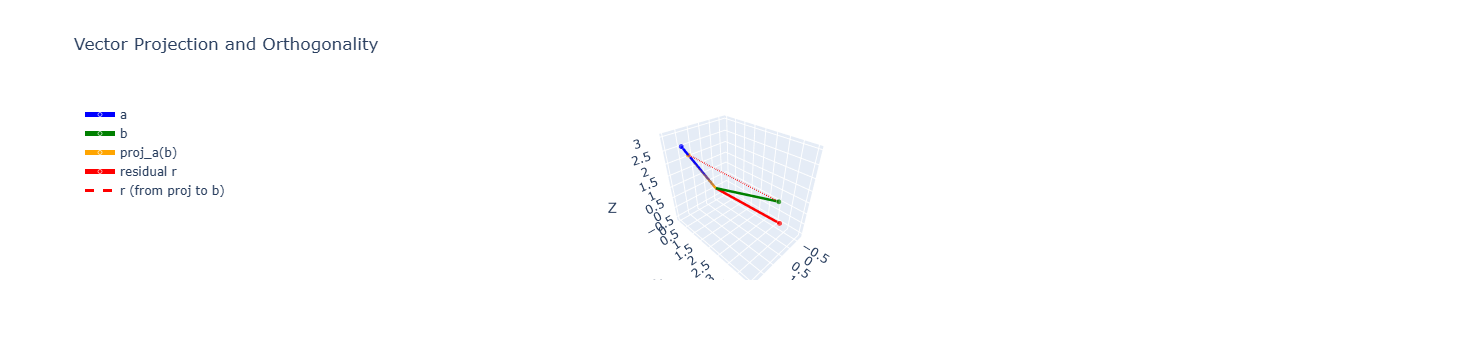

In [3]:
import plotly.graph_objects as go

origin = np.zeros(3)

def make_arrow(vec, color, name):
    return go.Scatter3d(
        x=[0, vec[0]], y=[0, vec[1]], z=[0, vec[2]],
        mode='lines+markers',
        line=dict(color=color, width=5),
        marker=dict(size=[2, 6], color=color),
        name=name
    )

fig = go.Figure()

fig.add_trace(make_arrow(a, 'blue', 'a'))
fig.add_trace(make_arrow(b, 'green', 'b'))
fig.add_trace(make_arrow(proj_a_b, 'orange', 'proj_a(b)'))
fig.add_trace(make_arrow(r, 'red', 'residual r'))

# Draw residual from tip of proj to tip of b
fig.add_trace(go.Scatter3d(
    x=[proj_a_b[0], b[0]], y=[proj_a_b[1], b[1]], z=[proj_a_b[2], b[2]],
    mode='lines',
    line=dict(color='red', width=3, dash='dash'),
    name='r (from proj to b)'
))

fig.update_layout(
    title='Vector Projection and Orthogonality',
    scene=dict(
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        aspectmode='data'
    ),
    legend=dict(x=0, y=1)
)

fig.show()

## Redundant Feature Detection via Projection & Rank

### Background
In real-world machine learning datasets, redundant features (multicollinear columns) might add unnecessary noise and increase computational cost. 
* **Matrix Rank:** Gives the total number of linearly independent columns in the dataset.
* **Vector Projection:** If a column vector $b$ is a scalar multiple of another column vector $a$, its orthogonal residual $r = b - \text{proj}_a(b)$ will be zero ($r = \vec{0}$).

---

### Problem Statement
You are given a dataset matrix $X$ containing $4$ data samples across $3$ features:
$$X = \begin{bmatrix} 1.0 & 2.0 & 3.0 \\ 2.0 & 4.0 & 6.0 \\ 3.0 & 6.0 & 8.0 \\ 4.0 & 8.0 & 1.0 \end{bmatrix}$$

**Tasks:**
1. Compute the rank of matrix $X$ using `np.linalg.matrix_rank` and check whether the matrix has full column rank.
2. Notice that Feature 1 (Column 1) might be redundant with Feature 0 (Column 0). Compute the projection of Column 1 onto Column 0:

   $$\text{proj}_{c_0}(c_1) = \frac{\langle c_0, c_1 \rangle}{\|c_0\|^2} c_0$$

3. Calculate the orthogonal residual $r = c_1 - \text{proj}_{c_0}(c_1)$ to verify if Column 1 is entirely collinear ( if $r = \vec{0}$?).

In [10]:
x = np.array([[1.0,2.0,3.0],[2.0,4.0,6.0],[3.0,6.0,8.0],[4.0,8.0,1.0]])
rank = np.linalg.matrix_rank(x)
print(f"Rank of the matrix x: {rank}")

# Check redundancy through projection of column 1 onto column 0
col0 = x[:,0]
col1 = x[:,1]
proj_col1_on_col0 = (np.dot(col0, col1) / np.dot(col0, col0)) * col0
residual = col1 - proj_col1_on_col0
print(f"Projection of column 1 onto column 0: {proj_col1_on_col0}")
print(f"Residual: {residual}")
print(f"Is column 1 fully redundant with column 0? {np.allclose(residual, 0)}")


Rank of the matrix x: 2
Projection of column 1 onto column 0: [2. 4. 6. 8.]
Residual: [0. 0. 0. 0.]
Is column 1 fully redundant with column 0? True
